#### Title: Linear Neural Network Models for Binary Classification

#### OBJECTIVES
* To evaluate the performance of a linear neural network for binary classification on the moons dataset.
* To compare the effectiveness of a basic linear model (ModelV0) on non-linear classification data.
class ModelV0(nn.Module):

def __init__(self):

    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=5) 

    self.layer_2 = nn.Linear(in_features=5, out_features=1)  

def forward(self, x):

    return self.layer_2(self.layer_1(x))


In [27]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [28]:
path='binary_classification_moons.csv'

data=pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


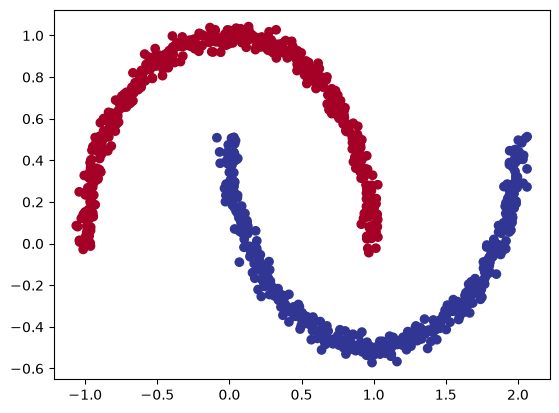

In [29]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [30]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [31]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [32]:
X.shape, y.shape

((1000, 2), (1000,))

In [33]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [34]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42,
                                                    stratify=y) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [35]:
# Make device agnostic code
device =  "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [36]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [37]:
model = model_0

In [38]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1317],
        [-0.1311],
        [-0.1339],
        [-0.1076],
        [-0.1425],
        [-0.1361],
        [-0.0419],
        [-0.1431],
        [-0.0809],
        [-0.1654]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0.])


In [39]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)
     

# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1317],
        [-0.1311],
        [-0.1339],
        [-0.1076],
        [-0.1425]], grad_fn=<SliceBackward0>)

In [40]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4671],
        [0.4673],
        [0.4666],
        [0.4731],
        [0.4644]], grad_fn=<SigmoidBackward0>)

In [41]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [42]:
y_test[:5]

tensor([1., 0., 0., 0., 1.])

In [43]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [44]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
         # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

Epoch: 0 | Train Loss: 0.69423 | Train Acc: 50.00% | Test Loss: 0.67922 | Test Acc: 59.50%
Epoch: 10 | Train Loss: 0.57738 | Train Acc: 77.75% | Test Loss: 0.56122 | Test Acc: 82.50%
Epoch: 20 | Train Loss: 0.49585 | Train Acc: 80.38% | Test Loss: 0.47679 | Test Acc: 83.00%
Epoch: 30 | Train Loss: 0.43715 | Train Acc: 81.12% | Test Loss: 0.41525 | Test Acc: 84.50%
Epoch: 40 | Train Loss: 0.39639 | Train Acc: 81.88% | Test Loss: 0.37180 | Test Acc: 85.50%
Epoch: 50 | Train Loss: 0.36840 | Train Acc: 82.00% | Test Loss: 0.34126 | Test Acc: 86.00%
Epoch: 60 | Train Loss: 0.34872 | Train Acc: 82.38% | Test Loss: 0.31927 | Test Acc: 86.00%
Epoch: 70 | Train Loss: 0.33427 | Train Acc: 82.88% | Test Loss: 0.30279 | Test Acc: 86.00%
Epoch: 80 | Train Loss: 0.32312 | Train Acc: 83.88% | Test Loss: 0.28990 | Test Acc: 86.00%
Epoch: 90 | Train Loss: 0.31411 | Train Acc: 84.38% | Test Loss: 0.27943 | Test Acc: 86.00%

Training complete!


In [45]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)
        # Print out what's happening
    if epoch % 10 == 0:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

Epoch: 0 | Train Loss: 0.30657 | Train Acc: 84.50% | Test Loss: 0.27066 | Test Acc: 86.00%


Epoch: 10 | Train Loss: 0.30008 | Train Acc: 84.50% | Test Loss: 0.26314 | Test Acc: 86.50%
Epoch: 20 | Train Loss: 0.29438 | Train Acc: 84.88% | Test Loss: 0.25659 | Test Acc: 86.50%
Epoch: 30 | Train Loss: 0.28932 | Train Acc: 85.00% | Test Loss: 0.25081 | Test Acc: 87.00%
Epoch: 40 | Train Loss: 0.28480 | Train Acc: 85.38% | Test Loss: 0.24568 | Test Acc: 87.50%
Epoch: 50 | Train Loss: 0.28075 | Train Acc: 85.38% | Test Loss: 0.24111 | Test Acc: 88.50%
Epoch: 60 | Train Loss: 0.27711 | Train Acc: 85.62% | Test Loss: 0.23701 | Test Acc: 89.00%
Epoch: 70 | Train Loss: 0.27386 | Train Acc: 86.00% | Test Loss: 0.23335 | Test Acc: 89.00%
Epoch: 80 | Train Loss: 0.27094 | Train Acc: 86.25% | Test Loss: 0.23006 | Test Acc: 89.00%
Epoch: 90 | Train Loss: 0.26834 | Train Acc: 86.50% | Test Loss: 0.22712 | Test Acc: 89.50%

Training complete!


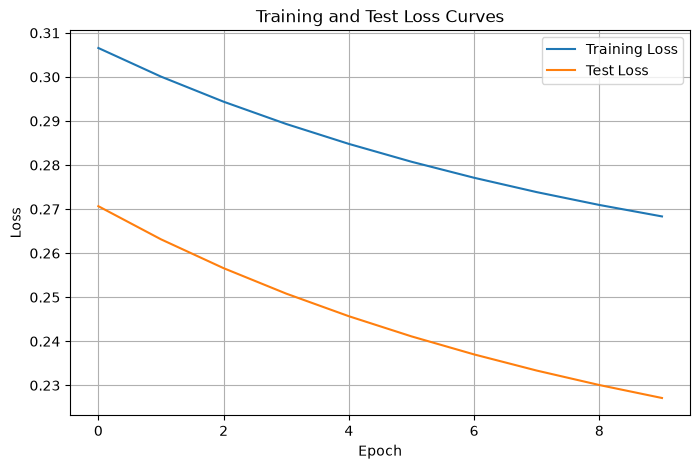

In [46]:
def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [47]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # Add ReLU activation function

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        # Now with ReLU activations in between the layers
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [48]:
model = model_1
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

In [49]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Put data to target device (if not already done, important for fresh runs)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)
         # Print out what's happening
    if epoch % 100 == 0 or epoch == epochs - 1:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

Epoch: 0 | Train Loss: 0.69550 | Train Acc: 37.12% | Test Loss: 0.69398 | Test Acc: 49.50%
Epoch: 100 | Train Loss: 0.40106 | Train Acc: 80.12% | Test Loss: 0.37510 | Test Acc: 83.00%
Epoch: 200 | Train Loss: 0.24124 | Train Acc: 89.00% | Test Loss: 0.20533 | Test Acc: 91.50%
Epoch: 300 | Train Loss: 0.19199 | Train Acc: 91.62% | Test Loss: 0.15837 | Test Acc: 93.00%
Epoch: 400 | Train Loss: 0.14695 | Train Acc: 94.12% | Test Loss: 0.12286 | Test Acc: 96.50%
Epoch: 500 | Train Loss: 0.09915 | Train Acc: 96.25% | Test Loss: 0.08473 | Test Acc: 98.00%
Epoch: 600 | Train Loss: 0.06205 | Train Acc: 99.00% | Test Loss: 0.05382 | Test Acc: 99.00%
Epoch: 700 | Train Loss: 0.03974 | Train Acc: 99.88% | Test Loss: 0.03484 | Test Acc: 99.50%
Epoch: 800 | Train Loss: 0.02740 | Train Acc: 100.00% | Test Loss: 0.02426 | Test Acc: 100.00%
Epoch: 900 | Train Loss: 0.02015 | Train Acc: 100.00% | Test Loss: 0.01801 | Test Acc: 100.00%
Epoch: 1000 | Train Loss: 0.01559 | Train Acc: 100.00% | Test Loss: 

In [50]:
def local_plot_boundary(model, X, y):
    # Create a grid of points covering the data area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the class for every point on the grid
    grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).round().numpy()

    # Plot the boundary colors and the actual data points
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.7, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")

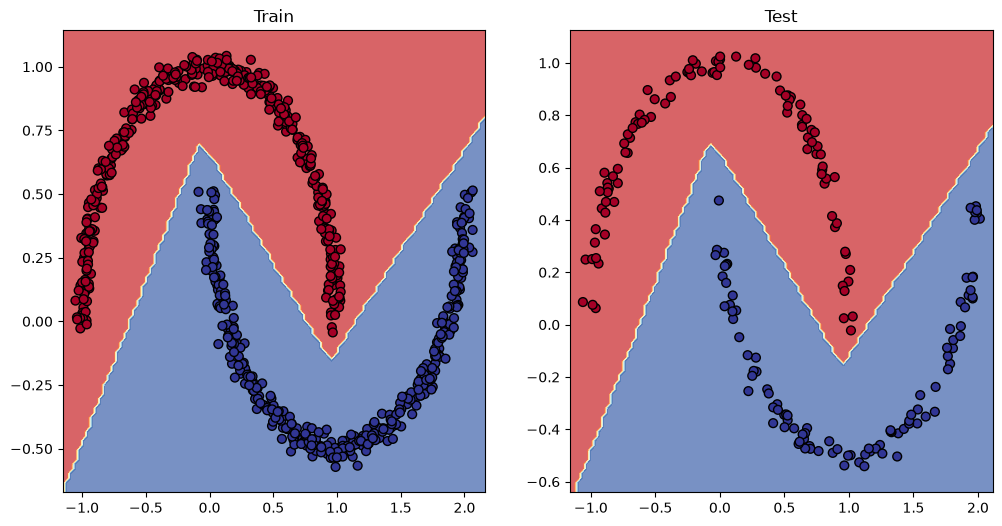

In [51]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
local_plot_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
local_plot_boundary(model, X_test, y_test)

plt.show()


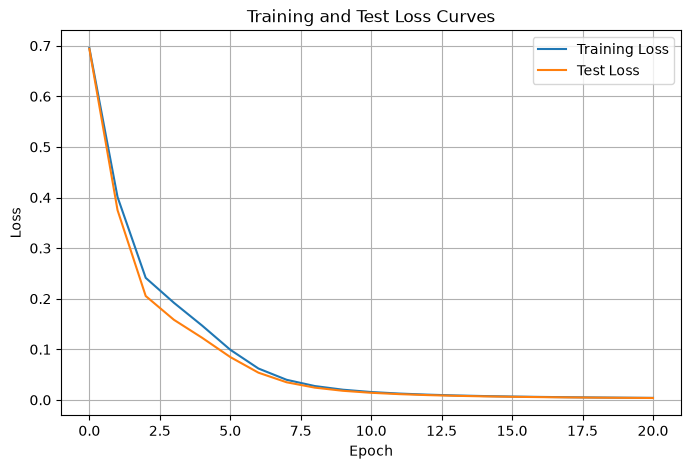

In [52]:
plot_loss_curves(train_losses, test_losses)

ModelV1 performs very well on the binary_classification_moons dataset because its extra hidden layer and ReLU activation functions enable it to learn complex, non-linear patterns. The model reached perfect accuracy on both the training and testing sets while maintaining very low loss, showing that it effectively learned the underlying moon-shaped distribution of the data. Its decision boundary accurately separates the two classes by following their curved structure, making it a much stronger model compared to ModelV0.